In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

In [2]:
X = []
Y = []

img_size = 224

# Kaggle training dataset path
base_path = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training"

classes = {
    'no_tumor': 0,
    'pituitary_tumor': 1,
    'glioma_tumor': 2,
    'meningioma_tumor': 3
}

for cls, label in classes.items():
    
    path = os.path.join(base_path, cls)

    for filename in os.listdir(path):

        img_path = os.path.join(path, filename)

        # Read image
        img = cv2.imread(img_path)

        # Skip corrupted images
        if img is None:
            continue

        # Resize image
        img = cv2.resize(img, (img_size, img_size))

        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Normalize image
        img = img.astype('float32') / 255.0

        # Flatten image for PCA
        img = img.flatten()

        # Store image and label
        X.append(img)
        Y.append(label)

# Convert into numpy arrays
X = np.array(X)
Y = np.array(Y)

print("X shape :", X.shape)
print("Y shape :", Y.shape)

X shape : (2870, 150528)
Y shape : (2870,)


In [3]:
tumor_counts = []

for cls, label in classes.items():
    
    count = np.sum(Y == label)
    
    tumor_counts.append([cls, count])

df_counts = pd.DataFrame(
    tumor_counts,
    columns=["Tumor Type", "Count"]
)

print(df_counts)

         Tumor Type  Count
0          no_tumor    395
1   pituitary_tumor    827
2      glioma_tumor    826
3  meningioma_tumor    822


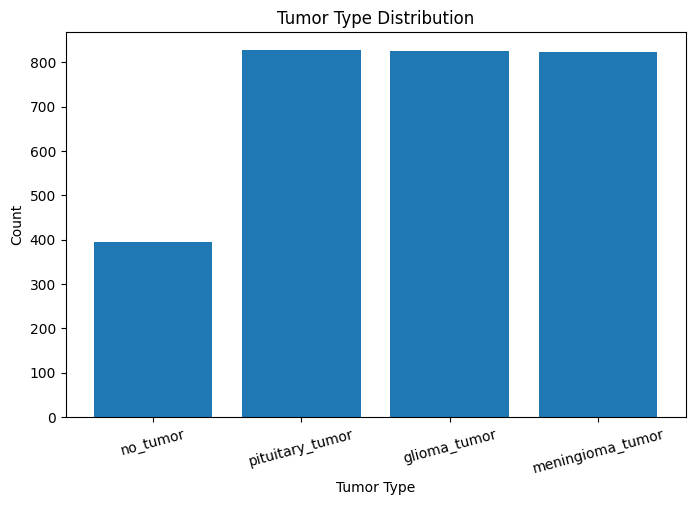

In [4]:
plt.figure(figsize=(8,5))

plt.bar(df_counts["Tumor Type"], df_counts["Count"])

plt.title("Tumor Type Distribution")
plt.xlabel("Tumor Type")
plt.ylabel("Count")

plt.xticks(rotation=15)

plt.show()

In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (2296, 150528)
Testing Shape  : (574, 150528)


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Complete")

Feature Scaling Complete


In [7]:
from sklearn.decomposition import PCA

# Reduce dimensions
pca = PCA(n_components=50)

# Fit on training data only
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform test data
X_test_pca = pca.transform(X_test_scaled)

print("Original Shape :", X_train_scaled.shape)

print("Reduced Shape  :", X_train_pca.shape)

# Explained variance
print("\nExplained Variance Ratio :")

print(np.sum(pca.explained_variance_ratio_))

Original Shape : (2296, 150528)
Reduced Shape  : (2296, 50)

Explained Variance Ratio :
0.6094555


In [8]:
svm_rbf = SVC(kernel='rbf')

svm_rbf.fit(X_train_pca, Y_train)

Y_pred_rbf = svm_rbf.predict(X_test_pca)

print("RBF Kernel Training Complete")

RBF Kernel Training Complete


In [9]:
accuracy_rbf = accuracy_score(Y_test, Y_pred_rbf)

f1_rbf = f1_score(
    Y_test,
    Y_pred_rbf,
    average='weighted'
)

cm_rbf = confusion_matrix(Y_test, Y_pred_rbf)

sensitivity_rbf = []

specificity_rbf = []

for i in range(len(classes)):
    
    TP = cm_rbf[i, i]
    
    FN = np.sum(cm_rbf[i, :]) - TP
    
    FP = np.sum(cm_rbf[:, i]) - TP
    
    TN = np.sum(cm_rbf) - (TP + FN + FP)
    
    sensitivity = TP / (TP + FN)
    
    specificity = TN / (TN + FP)
    
    sensitivity_rbf.append(sensitivity)
    
    specificity_rbf.append(specificity)

print("===== RBF KERNEL RESULTS =====\n")

print("Accuracy    :", accuracy_rbf)

print("F1 Score    :", f1_rbf)

print("Sensitivity :", np.mean(sensitivity_rbf))

print("Specificity :", np.mean(specificity_rbf))

print("\nClassification Report:\n")

print(classification_report(Y_test, Y_pred_rbf))

===== RBF KERNEL RESULTS =====

Accuracy    : 0.8344947735191638
F1 Score    : 0.8339343479946062
Sensitivity : 0.8277427724313291
Specificity : 0.9427105861011605

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.78      0.84        79
           1       0.91      0.96      0.94       166
           2       0.79      0.79      0.79       165
           3       0.77      0.77      0.77       164

    accuracy                           0.83       574
   macro avg       0.84      0.83      0.83       574
weighted avg       0.83      0.83      0.83       574



In [10]:
svm_linear = SVC(kernel='linear')

svm_linear.fit(X_train_pca, Y_train)

Y_pred_linear = svm_linear.predict(X_test_pca)

print("Linear Kernel Training Complete")

Linear Kernel Training Complete


In [11]:
accuracy_linear = accuracy_score(Y_test, Y_pred_linear)

f1_linear = f1_score(
    Y_test,
    Y_pred_linear,
    average='weighted'
)

cm_linear = confusion_matrix(Y_test, Y_pred_linear)

sensitivity_linear = []

specificity_linear = []

for i in range(len(classes)):
    
    TP = cm_linear[i, i]
    
    FN = np.sum(cm_linear[i, :]) - TP
    
    FP = np.sum(cm_linear[:, i]) - TP
    
    TN = np.sum(cm_linear) - (TP + FN + FP)
    
    sensitivity = TP / (TP + FN)
    
    specificity = TN / (TN + FP)
    
    sensitivity_linear.append(sensitivity)
    
    specificity_linear.append(specificity)

print("===== LINEAR KERNEL RESULTS =====\n")

print("Accuracy    :", accuracy_linear)

print("F1 Score    :", f1_linear)

print("Sensitivity :", np.mean(sensitivity_linear))

print("Specificity :", np.mean(specificity_linear))

print("\nClassification Report:\n")

print(classification_report(Y_test, Y_pred_linear))

===== LINEAR KERNEL RESULTS =====

Accuracy    : 0.7369337979094077
F1 Score    : 0.7334278678236851
Sensitivity : 0.7097488976366326
Specificity : 0.9094662763501973

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.53      0.61        79
           1       0.87      0.95      0.90       166
           2       0.73      0.70      0.72       165
           3       0.61      0.66      0.64       164

    accuracy                           0.74       574
   macro avg       0.73      0.71      0.72       574
weighted avg       0.74      0.74      0.73       574



In [12]:
comparison = pd.DataFrame({
    
    "Metric": [
        "Accuracy",
        "F1 Score",
        "Sensitivity",
        "Specificity"
    ],
    
    "RBF Kernel": [
        accuracy_rbf,
        f1_rbf,
        np.mean(sensitivity_rbf),
        np.mean(specificity_rbf)
    ],
    
    "Linear Kernel": [
        accuracy_linear,
        f1_linear,
        np.mean(sensitivity_linear),
        np.mean(specificity_linear)
    ]
})

comparison

,Metric,RBF Kernel,Linear Kernel
0,Accuracy,0.834495,0.736934
1,F1 Score,0.833934,0.733428
2,Sensitivity,0.827743,0.709749
3,Specificity,0.942711,0.909466


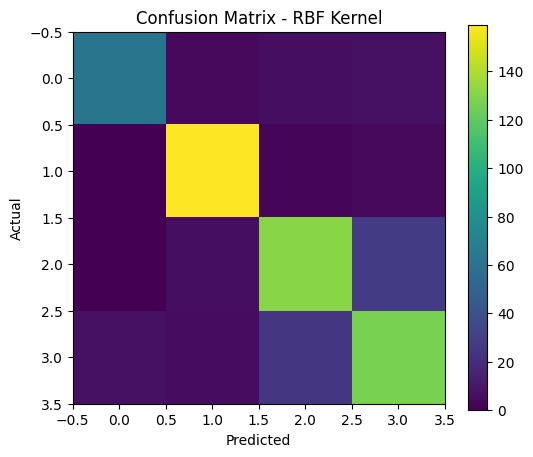

In [13]:
plt.figure(figsize=(6,5))

plt.imshow(cm_rbf)

plt.title("Confusion Matrix - RBF Kernel")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()